In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from pathlib import Path

processed = Path("../data/processed")
charts = Path("../reports/charts")
charts.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [7]:
fund_master = pd.read_csv(processed / "01_fund_master_cleaned.csv")
nav = pd.read_csv(processed / "02_nav_history_cleaned.csv")
performance = pd.read_csv(processed / "07_scheme_performance_cleaned.csv")
benchmarks = pd.read_csv(processed / "10_benchmark_indices_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmarks["date"] = pd.to_datetime(benchmarks["date"])

nav = nav.sort_values(["amfi_code", "date"])
benchmarks = benchmarks.sort_values(["index_name", "date"])

print(nav.shape)
print(fund_master.shape)
print(benchmarks["index_name"].unique())

(46000, 3)
(40, 15)
<ArrowStringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [8]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

daily_returns = nav.dropna(subset="daily_return").copy()

print(daily_returns.head())
print(daily_returns["daily_return"].describe())

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


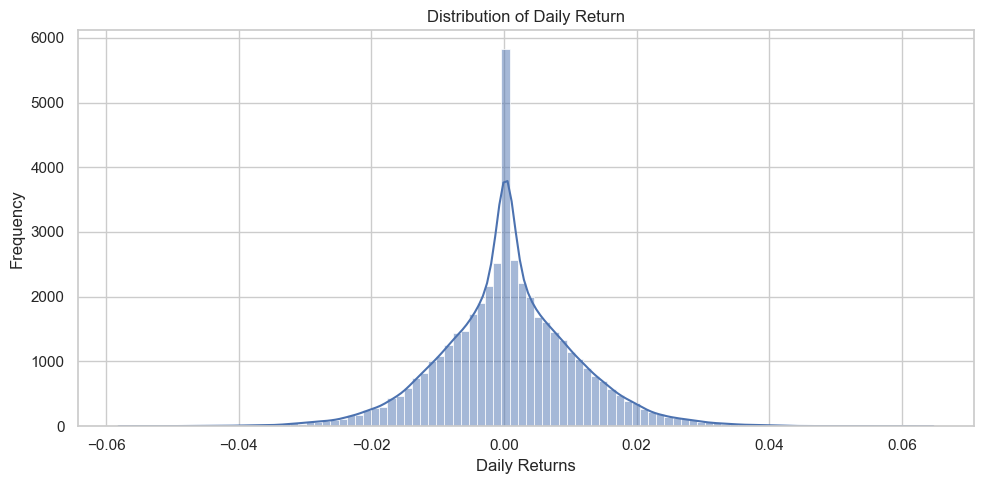

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(daily_returns["daily_return"], bins=100, kde=True)
plt.title("Distribution of Daily Return")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(charts / "daily_return_distribution.png", dpi=300)
plt.show()

In [10]:
def calculate_cagr(df, years):
    results = []

    latest_date = df["date"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    for amfi_code, group in df.groupby("amfi_code"):
        group = group.sort_values("date")

        end_row = group[group["date"] <= latest_date].tail(1)
        start_row = group[group["date"] <= start_date].tail(1)

        if len(start_row) == 0 or len(end_row) == 0:
            cagr = np.nan
        else:
            nav_start = start_row["nav"].values[0]
            nav_end = end_row["nav"].values[0]
            cagr = (nav_end / nav_start) ** (1 / years) - 1

        results.append({
            "amfi_code": amfi_code,
            f"cagr_{years}yr": cagr
        })

    return pd.DataFrame(results)

In [11]:
cagr_1yr = calculate_cagr(nav, 1)
cagr_3yr = calculate_cagr(nav, 3)
cagr_5yr = calculate_cagr(nav, 5)

cagr_table = cagr_1yr.merge(cagr_3yr, on="amfi_code", how="outer")
cagr_table = cagr_table.merge(cagr_5yr, on="amfi_code", how="outer")

cagr_table = cagr_table.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,expense_ratio_pct
0,100016,-0.022243,0.012926,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.55
1,100025,0.037050,0.039164,NaN,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,0.56
2,100033,0.532324,0.324425,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38
3,101206,0.479241,0.289677,NaN,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.60
4,101207,-0.239860,-0.041524,NaN,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.53


In [12]:
cagr_1yr = calculate_cagr(nav, 1)
cagr_3yr = calculate_cagr(nav, 3)
cagr_5yr = calculate_cagr(nav, 5)

cagr_table = cagr_1yr.merge(cagr_3yr, on="amfi_code", how="outer")
cagr_table = cagr_table.merge(cagr_5yr, on="amfi_code", how="outer")

cagr_table = cagr_table.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,expense_ratio_pct
0,100016,-0.022243,0.012926,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.55
1,100025,0.037050,0.039164,NaN,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,0.56
2,100033,0.532324,0.324425,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38
3,101206,0.479241,0.289677,NaN,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.60
4,101207,-0.239860,-0.041524,NaN,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.53


In [13]:
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

sharpe_results = []

for amfi_code, group in daily_returns.groupby("amfi_code"):
    mean_daily_return = group["daily_return"].mean()
    std_daily_return = group["daily_return"].std()

    sharpe = ((mean_daily_return - RF_DAILY) / std_daily_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

sharpe_df.sort_values("sharpe_ratio", ascending=False).head(10)

,amfi_code,sharpe_ratio,scheme_name,fund_house
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


In [14]:
sortino_results = []

for amfi_code, group in daily_returns.groupby("amfi_code"):
    mean_daily_return = group["daily_return"].mean()
    downside_returns = group[group["daily_return"] < 0]["daily_return"]
    downside_std = downside_returns.std()

    sortino = ((mean_daily_return - RF_DAILY) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

sortino_df.sort_values("sortino_ratio", ascending=False).head(10)

,amfi_code,sortino_ratio,scheme_name,fund_house
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


In [15]:
benchmark_pivot = benchmarks.pivot(
    index="date",
    columns="index_name",
    values="close_value"
).sort_index()

benchmark_returns = benchmark_pivot.pct_change().dropna()

nifty100_returns = benchmark_returns[["NIFTY100"]].reset_index()
nifty100_returns.columns = ["date", "nifty100_return"]

nifty50_returns = benchmark_returns[["NIFTY50"]].reset_index()
nifty50_returns.columns = ["date", "nifty50_return"]

In [17]:
alpha_beta_results = []

for amfi_code, group in daily_returns.groupby("amfi_code"):
    temp = group[["date", "daily_return"]].merge(
        nifty100_returns,
        on="date",
        how="inner"
    )

    if len(temp) > 30:
        result = linregress(
            temp["nifty100_return"],
            temp["daily_return"]
        )

        beta = result.slope
        alpha = result.intercept * 252

    else:
        beta = np.nan
        alpha = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

alpha_beta.to_csv(processed / "alpha_beta.csv", index=False)

alpha_beta.sort_values("alpha", ascending=False).head(10)

,amfi_code,alpha,beta,scheme_name,fund_house
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [19]:
temp.head()

,date,daily_return,nifty100_return
0,2022-01-04,-0.010498,-0.013540
1,2022-01-05,-0.002593,0.004003
2,2022-01-06,-0.008382,-0.002935
3,2022-01-07,0.011680,0.006150
4,2022-01-10,0.001356,-0.008351


In [24]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1

    max_dd = group["drawdown"].min()
    trough_date = group.loc[group["drawdown"].idxmin(), "date"]

    peak_date = group[
        group["date"] <= trough_date
    ].sort_values("nav", ascending=False).iloc[0]["date"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_dd,
        "peak_date": peak_date,
        "trough_date": trough_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

drawdown_df.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name,fund_house
22,119599,-0.525742,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.516778,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.354469,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,-0.311719,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.287060,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
7,102886,-0.280011,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
0,100016,-0.247344,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
29,120842,-0.240035,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF
11,118634,-0.233449,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
15,119093,-0.217514,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


In [33]:
scorecard = cagr_table.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sortino_df[["amfi_code", "sortino_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha", "beta"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown", "peak_date", "trough_date"]],
    on="amfi_code",
    how="left"
)

scorecard["rank_3yr_return"] = scorecard["cagr_3yr"].rank(pct=True)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["rank_alpha"] = scorecard["alpha"].rank(pct=True)

scorecard["rank_expense_inverse"] = scorecard["expense_ratio_pct"].rank(
    ascending=False,
    pct=True
)

scorecard["rank_max_dd_inverse"] = scorecard["max_drawdown"].rank(
    ascending=True,
    pct=True
)

scorecard["fund_score"] = (
    0.30 * scorecard["rank_3yr_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_inverse"] +
    0.10 * scorecard["rank_max_dd_inverse"]
) * 100

scorecard = scorecard.sort_values("fund_score", ascending=False)

scorecard.to_csv(processed / "fund_scorecard.csv", index=False)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,expense_ratio_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,peak_date,trough_date,rank_3yr_return,rank_sharpe,rank_alpha,rank_expense_inverse,rank_max_dd_inverse,fund_score
34,148567,0.203607,0.340009,NaN,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.46,1.448291,2.385644,0.269838,0.023684,-0.112657,2023-07-11,2023-10-20,0.975,1.000,0.850,0.4500,0.825,86.2500
25,120505,0.296047,0.317775,NaN,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.36,1.180101,2.029353,0.292636,0.000549,-0.181885,2024-10-24,2025-01-23,0.900,0.900,0.950,0.6500,0.400,82.2500
30,120843,0.266571,0.295828,NaN,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.45,1.306744,2.364320,0.273305,-0.022830,-0.129740,2022-03-07,2022-04-13,0.850,0.975,0.900,0.4750,0.700,82.0000
2,100033,0.532324,0.324425,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38,1.093699,1.829134,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,0.925,0.850,0.875,0.6000,0.525,80.7500
24,120504,0.130643,0.324874,NaN,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.80,1.026524,1.805294,0.211948,0.016232,-0.125883,2022-10-04,2023-05-30,0.950,0.775,0.700,0.7250,0.725,80.0000
16,119094,0.222611,0.351118,NaN,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,1.38,0.998231,1.703797,0.260767,-0.066265,-0.209609,2022-04-14,2022-08-11,1.000,0.750,0.800,0.6000,0.325,77.0000
19,119551,0.604373,0.304565,NaN,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.54,1.208267,2.140267,0.232010,-0.031751,-0.150124,2023-08-24,2024-02-05,0.875,0.925,0.775,0.2625,0.600,74.8125
36,148569,0.397518,0.291789,NaN,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.60,1.234930,2.146914,0.282704,0.018134,-0.163967,2023-08-10,2023-10-20,0.825,0.950,0.925,0.1125,0.500,73.6875
3,101206,0.479241,0.289677,NaN,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.60,1.027213,1.799563,0.213998,0.021086,-0.112916,2023-04-24,2023-07-05,0.800,0.800,0.725,0.1125,0.800,68.1875
21,119598,0.827761,0.266699,NaN,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,1.43,0.945308,1.675317,0.303370,-0.023196,-0.287060,2024-08-28,2025-05-14,0.725,0.675,1.000,0.5000,0.125,67.3750


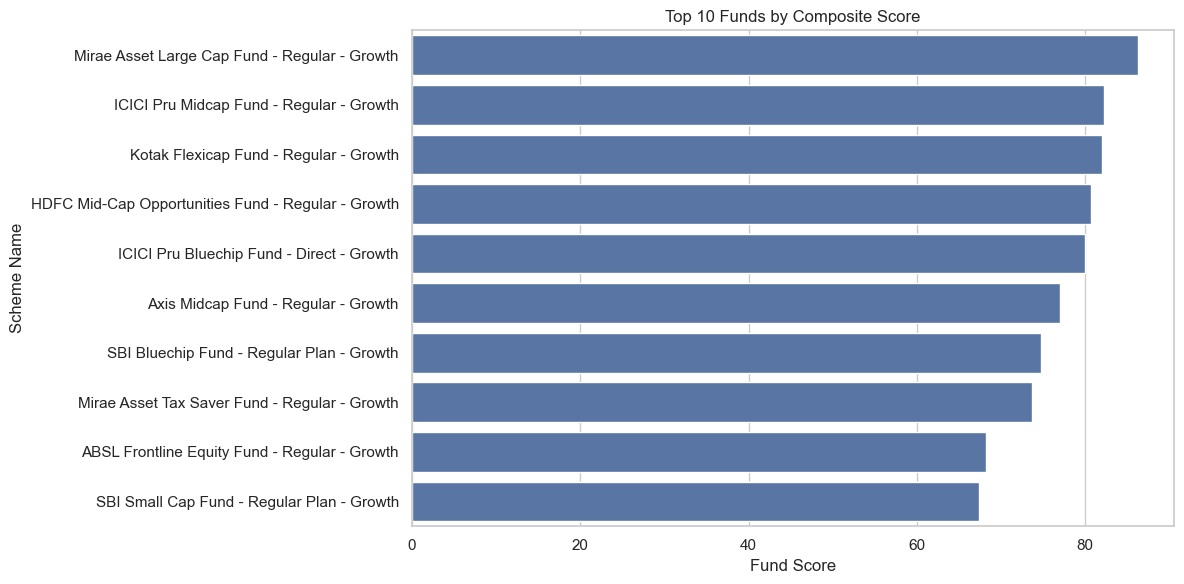

In [36]:
top10_scorecard = scorecard.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_scorecard,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Funds by Composite Score")
plt.xlabel("Fund Score")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(charts / "top10_fund_scorecard.png", dpi=300)
plt.show()

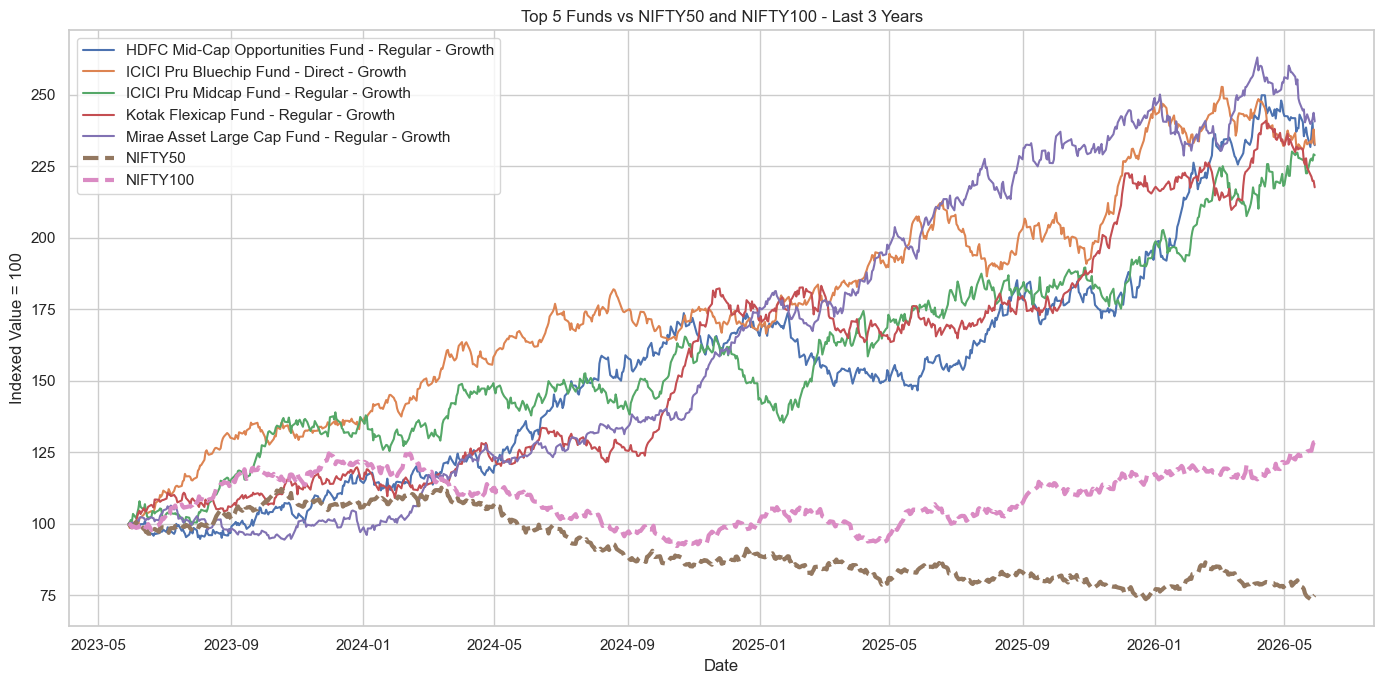

In [51]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

latest_date = top5_nav["date"].max()
start_date_3yr = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    top5_nav["date"] >= start_date_3yr
]

nav_pivot = top5_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
).sort_index()

nav_indexed = nav_pivot / nav_pivot.iloc[0] * 100

benchmark_3yr = benchmark_pivot[
    benchmark_pivot.index >= start_date_3yr
][["NIFTY50", "NIFTY100"]]

benchmark_indexed = benchmark_3yr / benchmark_3yr.iloc[0] * 100

plt.figure(figsize=(14, 7))

for col in nav_indexed.columns:
    scheme_name = fund_master.loc[
        fund_master["amfi_code"] == col,
        "scheme_name"
    ].values[0]

    plt.plot(nav_indexed.index, nav_indexed[col], label=scheme_name)

plt.plot(
    benchmark_indexed.index,
    benchmark_indexed["NIFTY50"],
    label="NIFTY50",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    benchmark_indexed.index,
    benchmark_indexed["NIFTY100"],
    label="NIFTY100",
    linewidth=3,
    linestyle="--"
)

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100 - Last 3 Years")
plt.xlabel("Date")
plt.ylabel("Indexed Value = 100")
plt.legend()
plt.tight_layout()
plt.savefig(charts / "benchmark_comparison_top5.png", dpi=300)
plt.show()

In [52]:
tracking_error_results = []

for amfi_code in top5_codes:
    fund_returns = daily_returns[
        daily_returns["amfi_code"] == amfi_code
    ][["date", "daily_return"]]

    temp = fund_returns.merge(
        nifty100_returns,
        on="date",
        how="inner"
    )

    temp["excess_return"] = temp["daily_return"] - temp["nifty100_return"]

    tracking_error = temp["excess_return"].std() * np.sqrt(252)

    scheme_name = fund_master.loc[
        fund_master["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    tracking_error_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "tracking_error_vs_nifty100": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_results)
tracking_error_df

,amfi_code,scheme_name,tracking_error_vs_nifty100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.191587
